# Metric 1 — LaTeX Preservation

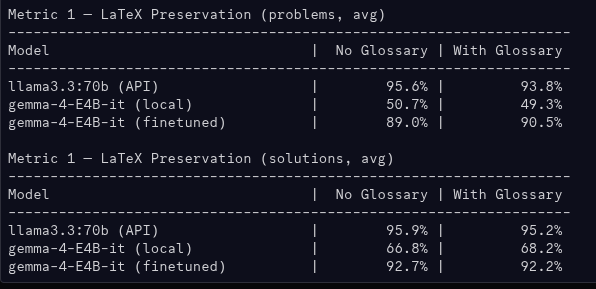

In [6]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

METRICS_DIR = Path('../../eval_results/metrics')
PATH = METRICS_DIR / 'metric_1.jsonl'

CONFIGS = [
    'api_no_glos', 'api_glos',
    'local_no_glos', 'local_glos',
    'finetuned_no_glos', 'finetuned_glos',
]
LABELS = {
    'api_no_glos':       'API\n(no glos)',
    'api_glos':          'API\n(glos)',
    'local_no_glos':     'Local\n(no glos)',
    'local_glos':        'Local\n(glos)',
    'finetuned_no_glos': 'Finetuned\n(no glos)',
    'finetuned_glos':    'Finetuned\n(glos)',
}

prob_rows, sol_rows = [], []
with open(PATH) as f:
    for line in f:
        rec = json.loads(line)
        idx = rec['idx']
        prob_rows.append({**{'idx': idx}, **{ck: (rec[ck]['problem'] if rec.get(ck) else None) for ck in CONFIGS}})
        sol_rows.append( {**{'idx': idx}, **{ck: (rec[ck]['solution'] if rec.get(ck) else None) for ck in CONFIGS}})

df_prob = pd.DataFrame(prob_rows).set_index('idx')
df_sol  = pd.DataFrame(sol_rows).set_index('idx')
print(f'Loaded {len(df_prob)} examples')
df_prob.head()

Loaded 300 examples


,api_no_glos,api_glos,local_no_glos,local_glos,finetuned_no_glos,finetuned_glos
idx,,,,,,
1251,1.0,1.0,0.0,0.0,1.0,1.0
1252,1.0,1.0,0.0,1.0,1.0,1.0
1253,1.0,1.0,1.0,1.0,1.0,1.0
1254,1.0,1.0,0.0,0.0,1.0,1.0
1255,1.0,1.0,1.0,1.0,1.0,1.0


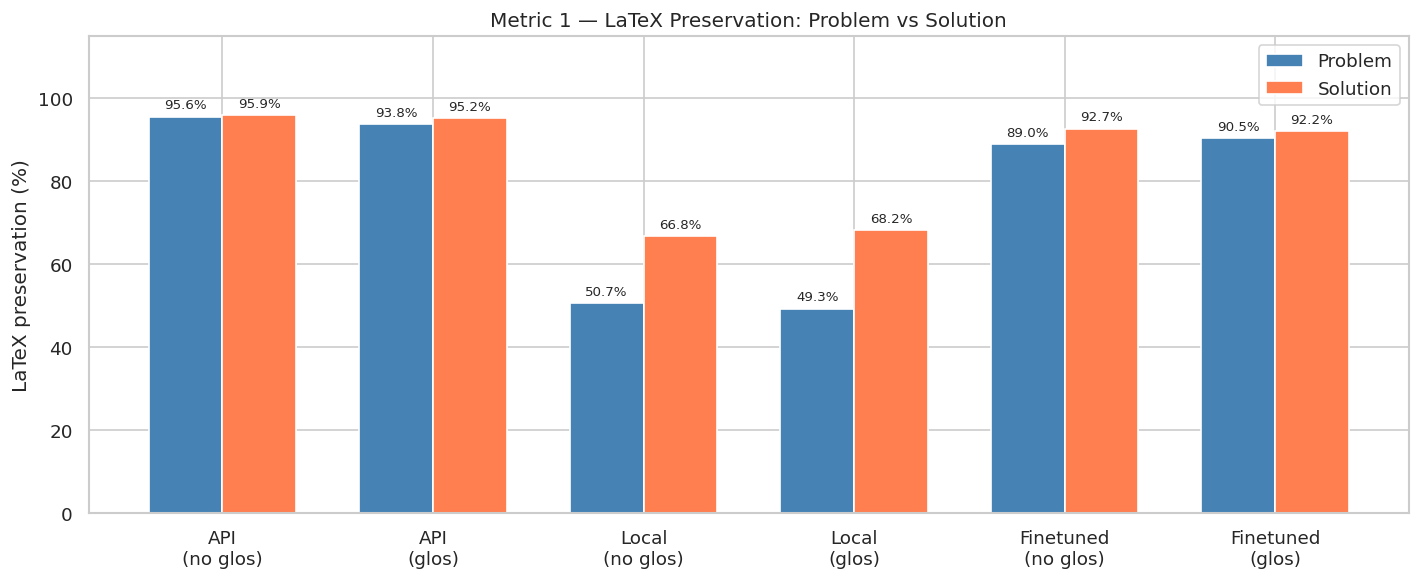

In [7]:
# --- Grouped bar: avg problem vs solution per config ---
prob_avgs = df_prob[CONFIGS].mean() * 100
sol_avgs  = df_sol[CONFIGS].mean()  * 100

x = np.arange(len(CONFIGS))
w = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - w/2, prob_avgs, w, label='Problem', color='steelblue')
b2 = ax.bar(x + w/2, sol_avgs,  w, label='Solution', color='coral')
ax.bar_label(b1, fmt='%.1f%%', padding=3, fontsize=8)
ax.bar_label(b2, fmt='%.1f%%', padding=3, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([LABELS[c] for c in CONFIGS])
ax.set_ylim(0, 115)
ax.set_ylabel('LaTeX preservation (%)')
ax.set_title('Metric 1 — LaTeX Preservation: Problem vs Solution')
ax.legend()
plt.tight_layout()
plt.show()

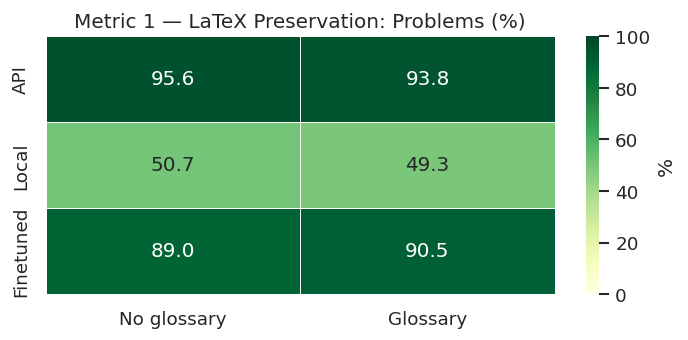

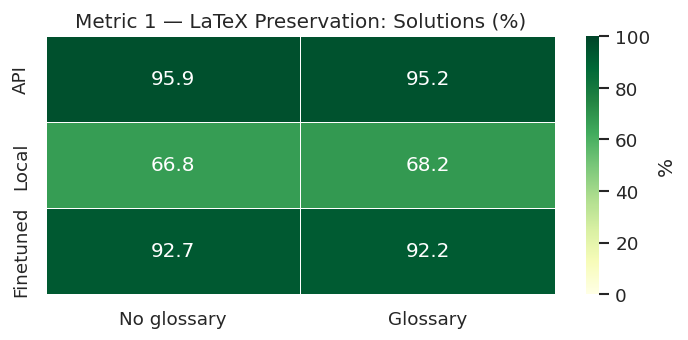

In [8]:
# --- Heatmap: model x glossary ---
models = ['api', 'local', 'finetuned']
for title, df in [('Problems', df_prob), ('Solutions', df_sol)]:
    heat = pd.DataFrame({
        'No glossary': [df[f'{m}_no_glos'].mean() * 100 for m in models],
        'Glossary':    [df[f'{m}_glos'].mean()    * 100 for m in models],
    }, index=['API', 'Local', 'Finetuned'])

    fig, ax = plt.subplots(figsize=(6, 3))
    sns.heatmap(heat, annot=True, fmt='.1f', cmap='YlGn', vmin=0, vmax=100,
                linewidths=0.5, ax=ax, cbar_kws={'label': '%'})
    ax.set_title(f'Metric 1 — LaTeX Preservation: {title} (%)')
    plt.tight_layout()
    plt.show()

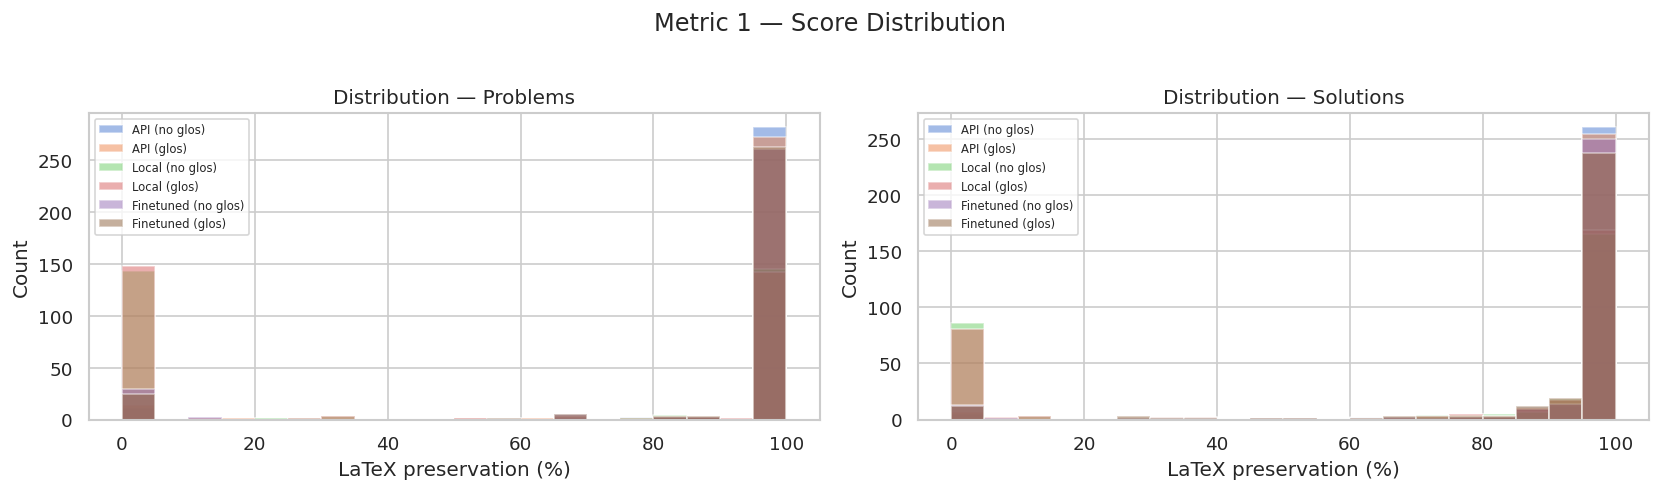

In [9]:
# --- Distribution: how often is preservation 0%, 50-99%, 100%? ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, df, title in zip(axes, [df_prob, df_sol], ['Problems', 'Solutions']):
    for ck in CONFIGS:
        vals = df[ck].dropna() * 100
        if len(vals): ax.hist(vals, bins=20, alpha=0.5, label=LABELS[ck].replace('\n', ' '))
    ax.set_xlabel('LaTeX preservation (%)')
    ax.set_ylabel('Count')
    ax.set_title(f'Distribution — {title}')
    ax.legend(fontsize=7)
plt.suptitle('Metric 1 — Score Distribution', y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_535650/2169473525.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Glossary', y='Difference (pp)', ax=ax,
/tmp/ipykernel_535650/2169473525.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=data, x='Glossary', y='Difference (pp)', ax=ax,
/tmp/ipykernel_535650/2169473525.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Glossary', y='Difference (pp)', ax=ax,
/tmp/ipykernel_535650/2169473525.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will 

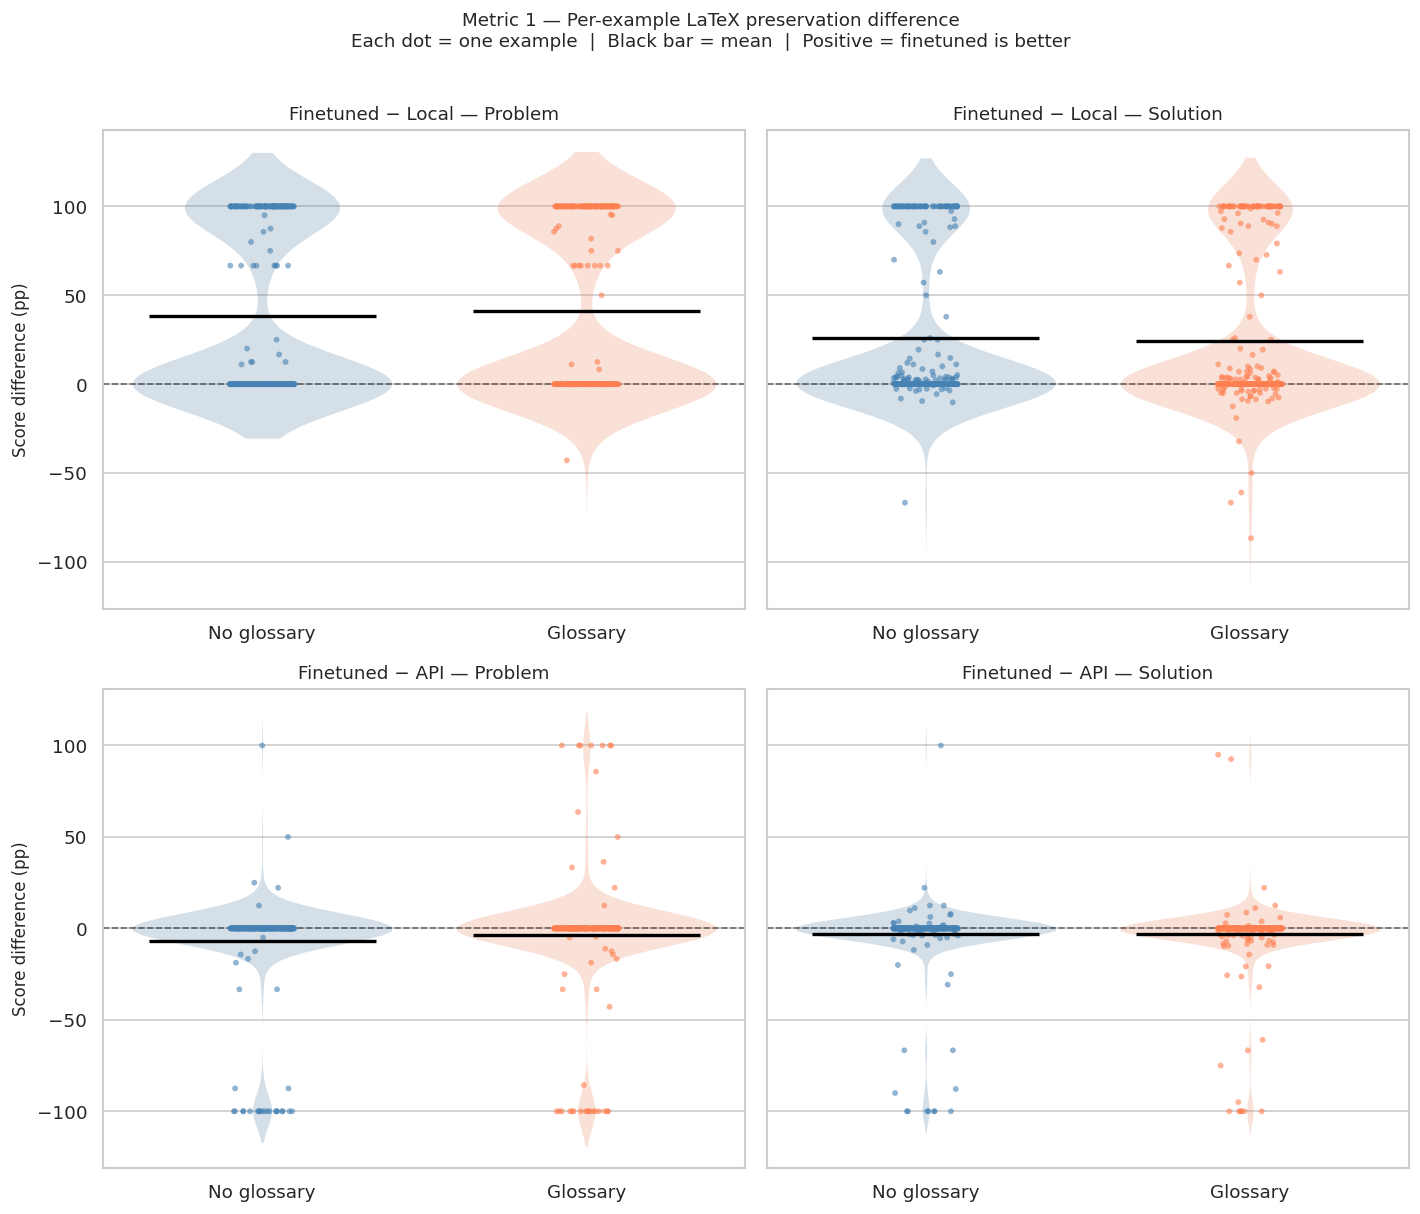

In [10]:
# --- Sina plot: per-example difference finetuned vs local and finetuned vs api ---
comparisons = [
    ('finetuned', 'local', 'Finetuned − Local'),
    ('finetuned', 'api',   'Finetuned − API'),
]

records = []
for model_a, model_b, cmp_label in comparisons:
    for part, df in [('Problem', df_prob), ('Solution', df_sol)]:
        for suffix, glos_label in [('no_glos', 'No glossary'), ('glos', 'Glossary')]:
            col_a, col_b = f'{model_a}_{suffix}', f'{model_b}_{suffix}'
            if col_a not in df.columns or col_b not in df.columns:
                continue
            diff = (df[[col_a, col_b]].dropna()
                    .assign(diff=lambda d: (d[col_a] - d[col_b]) * 100)['diff'])
            for val in diff:
                records.append({'Comparison': cmp_label, 'Part': part,
                                 'Glossary': glos_label, 'Difference (pp)': val})

df_diff = pd.DataFrame(records)

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey='row')

palette = {'No glossary': 'steelblue', 'Glossary': 'coral'}

for row_idx, cmp_label in enumerate(['Finetuned − Local', 'Finetuned − API']):
    for col_idx, part in enumerate(['Problem', 'Solution']):
        ax = axes[row_idx][col_idx]
        data = df_diff[(df_diff.Comparison == cmp_label) & (df_diff.Part == part)]

        # violin for shape reference
        sns.violinplot(data=data, x='Glossary', y='Difference (pp)', ax=ax,
                       palette=palette, inner=None, alpha=0.25, linewidth=0)

        # individual dots
        sns.stripplot(data=data, x='Glossary', y='Difference (pp)', ax=ax,
                      palette=palette, size=3.5, alpha=0.6, jitter=True)

        # mean line per group
        for i, glos_label in enumerate(['No glossary', 'Glossary']):
            mean = data[data.Glossary == glos_label]['Difference (pp)'].mean()
            ax.hlines(mean, i - 0.35, i + 0.35, colors='black', linewidth=2, zorder=5)

        ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
        ax.set_title(f'{cmp_label} — {part}', fontsize=11)
        ax.set_xlabel('')
        if col_idx == 0:
            ax.set_ylabel('Score difference (pp)', fontsize=10)
        else:
            ax.set_ylabel('')

plt.suptitle(
    'Metric 1 — Per-example LaTeX preservation difference\n'
    'Each dot = one example  |  Black bar = mean  |  Positive = finetuned is better',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.show()